## Use sensitivity data to compute recall 

In [2]:
TARGETS_BY_EXPERIMENT = {
    "lka_micron": ['vita_rae_mcg','folate_mcg', 'vitb12_mcg', 'fe_mg', 'zn_mg','avg_adult_education', 'log_exp'],
    "eth_micron": ['va_ai', 'fol_ai', 'vb12_ai','fe_ai', 'zn_ai','avg_adult_education', 'log_exp'],
    "nga_micron": ['va_ai', 'fol_ai', 'vb12_ai','fe_ai', 'zn_ai','avg_adult_education', 'log_exp'],
    "lka_vam":    ['education_score', 'log_income', 'space_per_person', 'FES', 'FCS','rCSI'],
    "moz_vam":    ['FCS', 'rCSI', 'FGVitA','FGProtein', 'FGHIron'],
    "yem_mvam":   ["log_exp_pp", "rCSI", "FCS"],
    "nga_mics":   ["space_per_person", "avg_adult_education", "wscore"],
    "zwe_mics":   ["space_per_person", "avg_adult_education", "wscore"]
}

# Fill the adm1 column name for each experiment
ADM1_COL_BY_EXPERIMENT = {
    "lka_micron": "adm1name",
    "eth_micron":"adm1name",
    "nga_micron":"adm1name",
    "lka_vam": "adm1name",
    "moz_vam": "adm1name",
    "yem_mvam":"adm1name",
    "nga_mics":"adm1name",
    "zwe_mics":"adm1name",
}

In [3]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.neighbors import BallTree

warnings.filterwarnings("ignore", category=FutureWarning)

EXPERIMENTS_ROOT = Path("/data/shared/fsibilla/clean_code/Q1/experiments")
OUTDIR = EXPERIMENTS_ROOT / "_recall_radius_results"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Radius in standardized target space
RADIUS = 0.5

# Query batch size for radius search
QUERY_BATCH_SIZE = 50000

# Optional debug subsample of full.csv
FULL_SUBSAMPLE = None   # e.g. 100_000

# If True, require neighbors to come from the same adm1
USE_ADM1 = True

print("Experiments root:", EXPERIMENTS_ROOT)
print("Output dir:", OUTDIR)
print("Radius:", RADIUS)
print("Batch size:", QUERY_BATCH_SIZE)
print("USE_ADM1:", USE_ADM1)

/data/shared/fsibilla/wfp-downscaling/.mamba/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Experiments root: /data/shared/fsibilla/clean_code/Q1/experiments
Output dir: /data/shared/fsibilla/clean_code/Q1/experiments/_recall_radius_results
Radius: 0.5
Batch size: 50000
USE_ADM1: True


In [4]:
VALID_TRAIN_SIZES = ['1', '2', '4', '8']

def parse_generated_path(path: Path):
    path = Path(path)
    parts = path.parts

    exp_name = None
    for i, p in enumerate(parts):
        if p == "experiments" and i + 1 < len(parts):
            exp_name = parts[i + 1]
            break
    if exp_name is None:
        raise ValueError(f"Could not parse experiment name from {path}")

    train_size = None
    for t in VALID_TRAIN_SIZES:
        if f"train_{t}_scaled" in str(path):
            train_size = t
            break
    if train_size is None:
        raise ValueError(f"Could not find a valid train size from {VALID_TRAIN_SIZES} in {path}")

    m_seed_dir = re.search(r"seed_(\d+)_scaled", str(path))
    m_file = re.search(r"generated_pool_(\d+)_seed(\d+)\.csv$", str(path))

    if not (m_seed_dir and m_file):
        raise ValueError(f"Path does not match expected structure: {path}")

    seed_dir = int(m_seed_dir.group(1))
    pool_size = int(m_file.group(1))
    seed_file = int(m_file.group(2))

    return {
        "experiment": exp_name,
        "train_size": train_size,
        "pool_size": pool_size,
        "seed_dir": seed_dir,
        "seed_file": seed_file,
        "seed": seed_file,
        "path": str(path),
    }


def drop_duplicated_columns(df, keep="first"):
    return df.loc[:, ~df.columns.duplicated(keep=keep)].copy()


def validate_columns_exist(df, cols, df_name="dataframe"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"{df_name}: missing columns {missing}")


def clean_numeric_block(df, cols):
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
        out.loc[~np.isfinite(out[c]), c] = np.nan
    return out


def fit_standardizer_from_full(full_df, cols):
    """
    Fit mean/std using full.csv only.
    """
    means = {}
    stds = {}
    for c in cols:
        x = pd.to_numeric(full_df[c], errors="coerce")
        x = x[np.isfinite(x)]
        if len(x) == 0:
            raise ValueError(f"No finite numeric data in full.csv for column {c}")
        mu = float(x.mean())
        sd = float(x.std())
        if not np.isfinite(sd) or sd == 0:
            sd = 1.0
        means[c] = mu
        stds[c] = sd
    return means, stds


def transform_standardize(df, cols, means, stds):
    arrs = []
    for c in cols:
        x = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
        z = (x - means[c]) / stds[c]
        arrs.append(z)
    return np.column_stack(arrs)


def radius_recall_balltree(full_X, gen_X, radius, batch_size=50000):
    """
    Return fraction of rows in full_X with at least one neighbor in gen_X within radius.
    """
    if len(full_X) == 0:
        return np.nan, 0, len(gen_X)
    if len(gen_X) == 0:
        return 0.0, len(full_X), 0

    tree = BallTree(gen_X, metric="euclidean")

    hits = np.zeros(len(full_X), dtype=bool)

    for start in range(0, len(full_X), batch_size):
        end = min(start + batch_size, len(full_X))
        inds = tree.query_radius(full_X[start:end], r=radius, count_only=False)
        hits[start:end] = np.fromiter((len(x) > 0 for x in inds), dtype=bool, count=end-start)

    return float(hits.mean()), int(len(full_X)), int(len(gen_X))


def compute_recall_radius(
    full_df,
    gen_df,
    target_cols,
    radius,
    batch_size=50000,
    full_subsample=None,
    adm1_col=None,
):
    """
    Recall with radius neighborhood in standardized target space.
    If adm1_col is provided, matching is restricted within adm1 groups.
    """
    needed_cols = list(target_cols) + ([adm1_col] if adm1_col is not None else [])

    full_df = drop_duplicated_columns(full_df)
    gen_df = drop_duplicated_columns(gen_df)

    validate_columns_exist(full_df, needed_cols, df_name="full_df")
    validate_columns_exist(gen_df, needed_cols, df_name="gen_df")

    full_use = full_df[needed_cols].copy()
    gen_use = gen_df[needed_cols].copy()

    full_use = clean_numeric_block(full_use, target_cols)
    gen_use = clean_numeric_block(gen_use, target_cols)

    full_use = full_use.dropna(subset=target_cols + ([adm1_col] if adm1_col else [])).copy()
    gen_use = gen_use.dropna(subset=target_cols + ([adm1_col] if adm1_col else [])).copy()

    if adm1_col is not None:
        full_use[adm1_col] = full_use[adm1_col].astype(str)
        gen_use[adm1_col] = gen_use[adm1_col].astype(str)

    if full_subsample is not None and len(full_use) > full_subsample:
        full_use = full_use.sample(full_subsample, random_state=0)

    if len(full_use) == 0:
        return {
            "recall": np.nan,
            "n_full_used": 0,
            "n_gen_used": len(gen_use),
            "n_groups": 0,
        }

    means, stds = fit_standardizer_from_full(full_use, target_cols)

    if adm1_col is None:
        full_X = transform_standardize(full_use, target_cols, means, stds)
        gen_X = transform_standardize(gen_use, target_cols, means, stds)

        recall, n_full_used, n_gen_used = radius_recall_balltree(
            full_X, gen_X, radius=radius, batch_size=batch_size
        )

        return {
            "recall": recall,
            "n_full_used": n_full_used,
            "n_gen_used": n_gen_used,
            "n_groups": 1,
        }

    # adm1-restricted recall
    hits_total = 0
    n_full_total = 0
    n_gen_total = len(gen_use)
    n_groups = 0

    full_groups = full_use.groupby(adm1_col, sort=False)
    gen_groups = {k: g for k, g in gen_use.groupby(adm1_col, sort=False)}

    for adm1_value, full_g in full_groups:
        gen_g = gen_groups.get(adm1_value, None)
        n_groups += 1

        full_X = transform_standardize(full_g, target_cols, means, stds)
        gen_X = (
            transform_standardize(gen_g, target_cols, means, stds)
            if gen_g is not None and len(gen_g) > 0
            else np.empty((0, len(target_cols)), dtype=float)
        )

        recall_g, n_full_g, _ = radius_recall_balltree(
            full_X, gen_X, radius=radius, batch_size=batch_size
        )

        if np.isnan(recall_g):
            continue

        hits_total += recall_g * n_full_g
        n_full_total += n_full_g

    recall = hits_total / n_full_total if n_full_total > 0 else np.nan

    return {
        "recall": float(recall) if np.isfinite(recall) else np.nan,
        "n_full_used": int(n_full_total),
        "n_gen_used": int(n_gen_total),
        "n_groups": int(n_groups),
    }


def quick_scale_check(full_df, gen_df, cols):
    rows = []
    for c in cols:
        f = pd.to_numeric(full_df[c], errors="coerce")
        g = pd.to_numeric(gen_df[c], errors="coerce")
        f = f[np.isfinite(f)]
        g = g[np.isfinite(g)]
        rows.append({
            "col": c,
            "full_mean": f.mean() if len(f) else np.nan,
            "gen_mean": g.mean() if len(g) else np.nan,
            "full_std": f.std() if len(f) else np.nan,
            "gen_std": g.std() if len(g) else np.nan,
            "full_n": len(f),
            "gen_n": len(g),
        })
    return pd.DataFrame(rows)

In [5]:
generated_files = sorted(
    EXPERIMENTS_ROOT.glob("*_*/results/train_*_scaled/seed_*_scaled/generated_pool_*_seed*.csv")
)

meta_rows = []
bad_rows = []

for p in generated_files:
    try:
        meta_rows.append(parse_generated_path(p))
    except Exception as e:
        bad_rows.append({
            "path": str(p),
            "error": repr(e),
        })

meta_df = pd.DataFrame(meta_rows).sort_values(
    ["experiment", "train_size", "seed"]
).reset_index(drop=True)

bad_df = pd.DataFrame(bad_rows)

print("Matched by glob:", len(generated_files))
print("Parsed successfully:", len(meta_df))
print("Malformed:", len(bad_df))

display(meta_df.head())

if len(bad_df):
    display(bad_df.head(20))

Matched by glob: 490
Parsed successfully: 145
Malformed: 345


,experiment,train_size,pool_size,seed_dir,seed_file,seed,path
0,eth_micron,1,1,1,1,1,/data/shared/fsibilla/clean_code/Q1/experiment...
1,eth_micron,1,1,2,2,2,/data/shared/fsibilla/clean_code/Q1/experiment...
2,eth_micron,1,1,3,3,3,/data/shared/fsibilla/clean_code/Q1/experiment...
3,eth_micron,1,1,4,4,4,/data/shared/fsibilla/clean_code/Q1/experiment...
4,eth_micron,1,1,5,5,5,/data/shared/fsibilla/clean_code/Q1/experiment...


,path,error
0,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."
1,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."
2,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."
3,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."
4,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."
5,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."
6,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."
7,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."
8,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."
9,/data/shared/fsibilla/clean_code/Q1/experiment...,"ValueError(""Could not find a valid train size ..."


In [6]:
found_experiments = sorted(meta_df["experiment"].unique().tolist())
configured_targets = sorted(TARGETS_BY_EXPERIMENT.keys())
configured_adm1 = sorted(ADM1_COL_BY_EXPERIMENT.keys())

missing_targets = sorted(set(found_experiments) - set(configured_targets))
missing_adm1 = sorted(set(found_experiments) - set(configured_adm1)) if USE_ADM1 else []

print("Found experiments:", found_experiments)
print("Missing target configs:", missing_targets)
print("Missing adm1 configs:", missing_adm1)

Found experiments: ['eth_micron', 'lka_micron', 'lka_vam', 'moz_vam', 'nga_micron', 'nga_mics', 'yem_mvam', 'zwe_mics']
Missing target configs: []
Missing adm1 configs: []


In [7]:
results = []
full_cache = {}

for row in tqdm(meta_df.to_dict(orient="records"), total=len(meta_df)):
    exp = row["experiment"]

    if exp not in TARGETS_BY_EXPERIMENT:
        results.append({**row, "status": "error: missing target config"})
        continue

    if USE_ADM1 and exp not in ADM1_COL_BY_EXPERIMENT:
        results.append({**row, "status": "error: missing adm1 config"})
        continue

    targets = TARGETS_BY_EXPERIMENT[exp]
    adm1_col = ADM1_COL_BY_EXPERIMENT[exp] if USE_ADM1 else None
    needed_cols = targets + ([adm1_col] if adm1_col is not None else [])

    gen_path = Path(row["path"])
    full_path = EXPERIMENTS_ROOT / exp / "full.csv"

    try:
        if exp not in full_cache:
            full_df = drop_duplicated_columns(pd.read_csv(full_path))
            validate_columns_exist(full_df, needed_cols, df_name=f"{exp}/full.csv")
            full_cache[exp] = full_df
        else:
            full_df = full_cache[exp]

        gen_df = drop_duplicated_columns(pd.read_csv(gen_path))
        validate_columns_exist(gen_df, needed_cols, df_name=str(gen_path))

        metrics = compute_recall_radius(
            full_df=full_df,
            gen_df=gen_df,
            target_cols=targets,
            radius=RADIUS,
            batch_size=QUERY_BATCH_SIZE,
            full_subsample=FULL_SUBSAMPLE,
            adm1_col=adm1_col,
        )

        results.append({
            **row,
            "adm1_col": adm1_col,
            "target_vars": ",".join(targets),
            "n_target_vars": len(targets),
            "radius": RADIUS,
            "recall": metrics["recall"],
            "n_full_used": metrics["n_full_used"],
            "n_gen_used": metrics["n_gen_used"],
            "n_groups": metrics["n_groups"],
            "status": "ok",
        })

    except Exception as e:
        results.append({
            **row,
            "adm1_col": adm1_col,
            "target_vars": ",".join(targets),
            "n_target_vars": len(targets),
            "radius": RADIUS,
            "recall": np.nan,
            "n_full_used": np.nan,
            "n_gen_used": np.nan,
            "n_groups": np.nan,
            "status": f"error: {repr(e)}",
        })

results_df = pd.DataFrame(results).sort_values(
    ["experiment", "train_size", "seed"]
).reset_index(drop=True)

suffix = "with_adm1" if USE_ADM1 else "no_adm1"
results_csv = "/data/shared/fsibilla/clean_code/Q0/recall/recall_radius_results.csv"
results_df.to_csv(results_csv, index=False)

print("Saved results to:", results_csv)
display(results_df["status"].value_counts(dropna=False))
display(results_df.head())

100%|██████████| 145/145 [05:59<00:00,  2.48s/it]

Saved results to: /data/shared/fsibilla/clean_code/Q0/recall/recall_radius_results.csv


status
ok    145
Name: count, dtype: int64

,experiment,train_size,pool_size,seed_dir,seed_file,seed,path,adm1_col,target_vars,n_target_vars,radius,recall,n_full_used,n_gen_used,n_groups,status
0,eth_micron,1,1,1,1,1,/data/shared/fsibilla/clean_code/Q1/experiment...,adm1name,"va_ai,fol_ai,vb12_ai,fe_ai,zn_ai,avg_adult_edu...",7,0.5,0.302864,6214,6214,11,ok
1,eth_micron,1,1,2,2,2,/data/shared/fsibilla/clean_code/Q1/experiment...,adm1name,"va_ai,fol_ai,vb12_ai,fe_ai,zn_ai,avg_adult_edu...",7,0.5,0.339234,6214,6214,11,ok
2,eth_micron,1,1,3,3,3,/data/shared/fsibilla/clean_code/Q1/experiment...,adm1name,"va_ai,fol_ai,vb12_ai,fe_ai,zn_ai,avg_adult_edu...",7,0.5,0.286772,6214,6214,11,ok
3,eth_micron,1,1,4,4,4,/data/shared/fsibilla/clean_code/Q1/experiment...,adm1name,"va_ai,fol_ai,vb12_ai,fe_ai,zn_ai,avg_adult_edu...",7,0.5,0.317992,6214,6214,11,ok
4,eth_micron,1,1,5,5,5,/data/shared/fsibilla/clean_code/Q1/experiment...,adm1name,"va_ai,fol_ai,vb12_ai,fe_ai,zn_ai,avg_adult_edu...",7,0.5,0.316704,6214,6214,11,ok


In [8]:
ok_df = results_df[results_df["status"] == "ok"].copy()

summary_df = (
    ok_df.groupby(["experiment", "train_size"], as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        recall_min=("recall", "min"),
        recall_max=("recall", "max"),
        n_seeds=("seed", "nunique"),
        n_target_vars=("n_target_vars", "first"),
        adm1_col=("adm1_col", "first"),
        radius=("radius", "first"),
    )
    .sort_values(["experiment", "train_size"])
    .reset_index(drop=True)
)

summary_csv = "/data/shared/fsibilla/clean_code/Q0/recall/recall_radius_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved summary to:", summary_csv)
display(summary_df.head(20))

Saved summary to: /data/shared/fsibilla/clean_code/Q0/recall/recall_radius_summary.csv


,experiment,train_size,recall_mean,recall_std,recall_min,recall_max,n_seeds,n_target_vars,adm1_col,radius
0,eth_micron,1,0.312713,0.019475,0.286772,0.339234,5,7,adm1name,0.5
1,eth_micron,2,0.361249,0.016293,0.342131,0.386225,5,7,adm1name,0.5
2,eth_micron,4,0.391213,0.012273,0.377213,0.407628,5,7,adm1name,0.5
3,eth_micron,8,0.417831,0.004393,0.412617,0.423882,5,7,adm1name,0.5
4,lka_micron,1,0.183385,0.017979,0.163235,0.207885,5,7,adm1name,0.5
5,lka_micron,2,0.211823,0.023369,0.185033,0.235259,5,7,adm1name,0.5
6,lka_micron,4,0.236615,0.016097,0.215821,0.258764,5,7,adm1name,0.5
7,lka_micron,8,0.261959,0.018801,0.230286,0.280512,5,7,adm1name,0.5
8,lka_vam,1,0.201781,0.034465,0.142581,0.232781,5,6,adm1name,0.5
9,lka_vam,2,0.191608,0.046929,0.115804,0.234369,5,6,adm1name,0.5


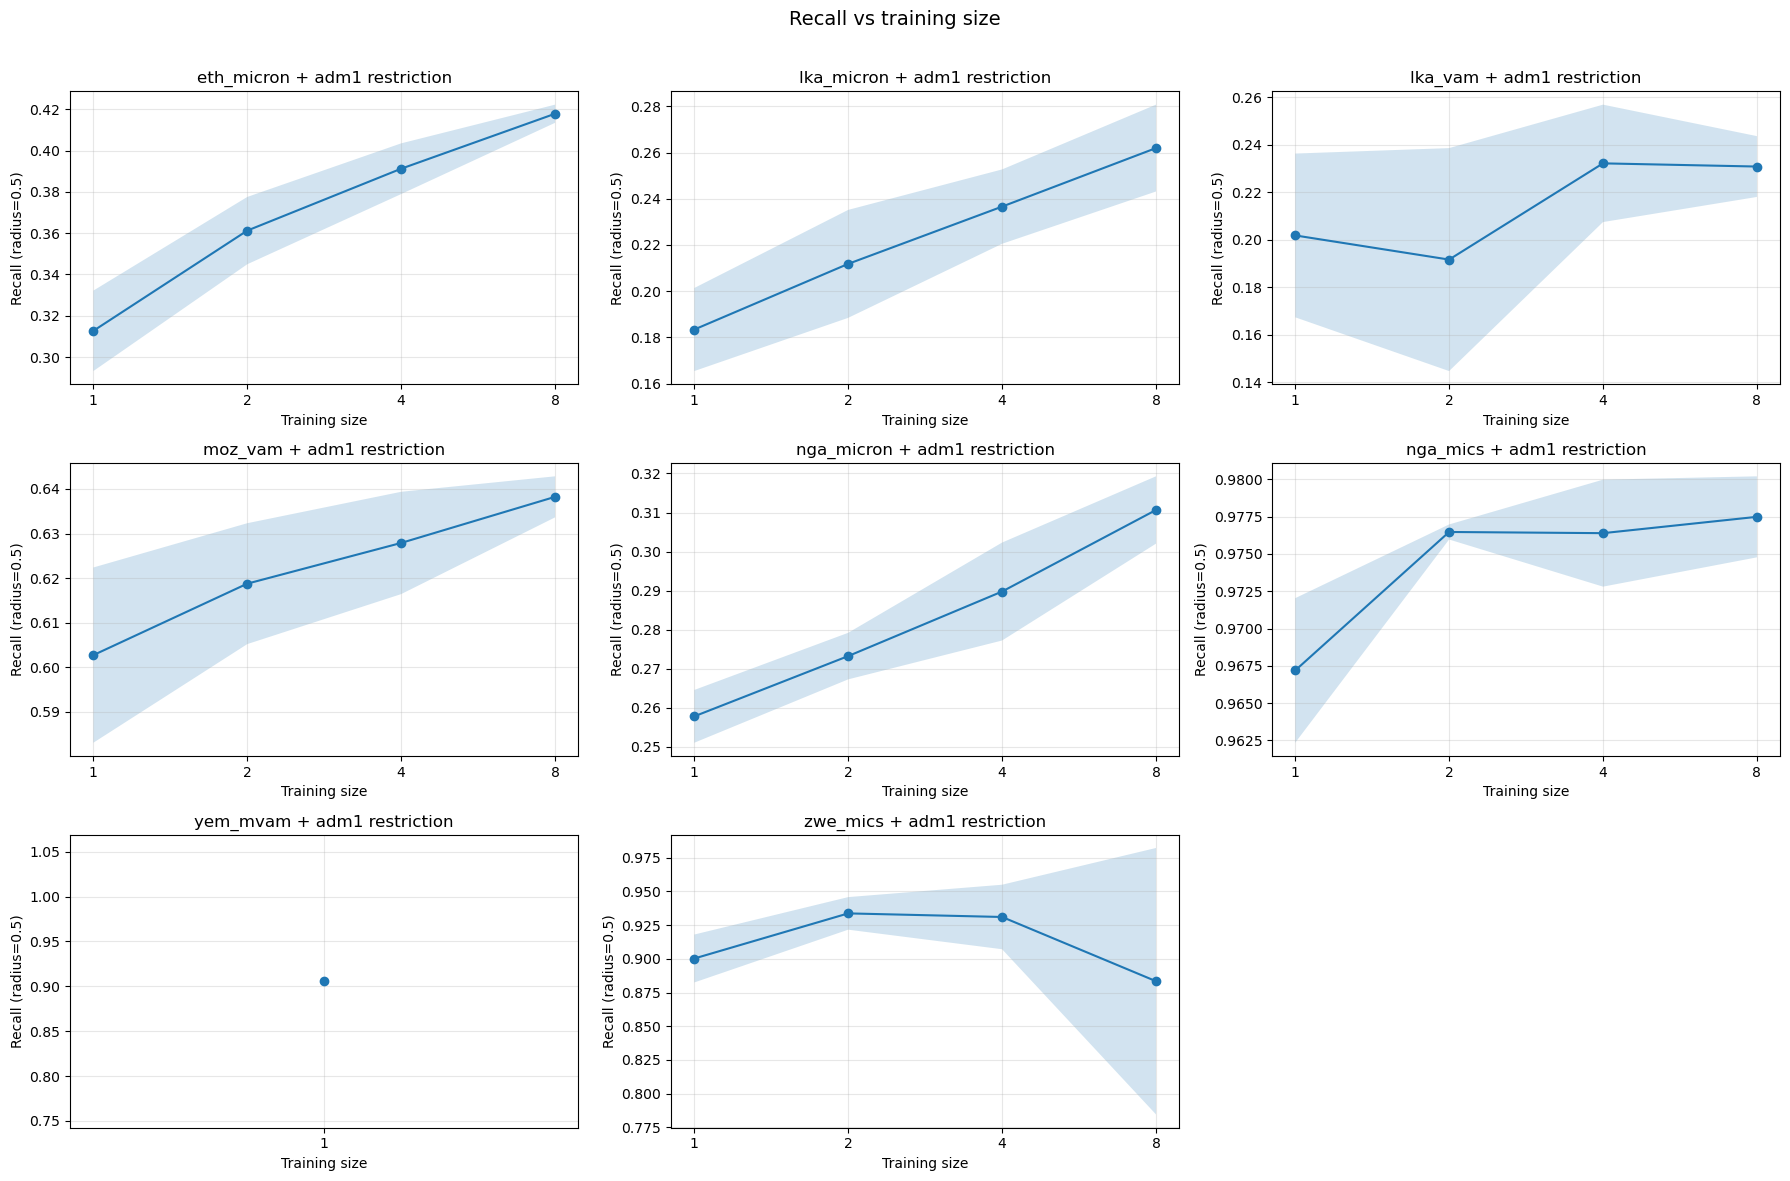

In [10]:
import math

experiments_to_plot = sorted(summary_df["experiment"].unique())
n_exp = len(experiments_to_plot)

ncols = min(3, n_exp)
nrows = math.ceil(n_exp / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
axes = axes.flatten()

for ax, exp in zip(axes, experiments_to_plot):
    sub = summary_df[summary_df["experiment"] == exp].sort_values("train_size")

    ax.plot(sub["train_size"], sub["recall_mean"], marker="o")
    ax.fill_between(
        sub["train_size"],
        sub["recall_mean"] - sub["recall_std"].fillna(0),
        sub["recall_mean"] + sub["recall_std"].fillna(0),
        alpha=0.2,
    )

    ax.set_xlabel("Training size")
    ax.set_ylabel(f"Recall (radius={RADIUS})")
    title_suffix = " + adm1 restriction" if USE_ADM1 else ""
    ax.set_title(f"{exp}{title_suffix}")
    ax.grid(True, alpha=0.3)

# Hide unused axes
for ax in axes[n_exp:]:
    ax.axis("off")

fig.suptitle("Recall vs training size", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()